In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt


In [2]:
train_data = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\train_data.csv")
test_data  = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\test_data.csv")


In [3]:
feature_cols = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "Stories",
    "GarageSpaces", "ParkingTotal",
    "AttachedGarageYN", "FireplaceYN", "PoolPrivateYN",
    "ViewYN", "NewConstructionYN",
    "DaysOnMarket", "AssociationFee",
    "Latitude", "Longitude",
    "City_encoded", "PostalCode_encoded",
    "CountyOrParish_encoded", "HighSchoolDistrict_encoded",
]
X_train = train_data[feature_cols]
y_train = train_data["ClosePrice"]

X_test = test_data[feature_cols]
y_test = test_data["ClosePrice"]

# Final NaN check
print(f"Missing in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing in X_test:  {X_test.isnull().sum().sum()}")
print(f"Features: {len(feature_cols)}")

Missing in X_train: 0
Missing in X_test:  0
Features: 21


In [4]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
print("Linear Regression trained!")

Linear Regression trained!


In [13]:
# Check price distribution
print("ClosePrice stats:")
print(y_train.describe())
print(f"\nProperties over $5M: {(y_train > 5_000_000).sum()}")
print(f"Properties under $100k: {(y_train < 100_000).sum()}")

# Remove price outliers — keep only $100k to $10M
# This removes extreme luxury properties that confuse the model
price_mask_train = (y_train >= 100_000) & (y_train <= 10_000_000)
price_mask_test  = (y_test  >= 100_000) & (y_test  <= 10_000_000)

X_train_clean = X_train[price_mask_train]
y_train_clean = y_train[price_mask_train]

X_test_clean = X_test[price_mask_test]
y_test_clean = y_test[price_mask_test]

print(f"\nTrain rows after removing outliers: {len(X_train_clean)}")
print(f"Test rows after removing outliers:  {len(X_test_clean)}")

ClosePrice stats:
count    4.970300e+04
mean     1.347440e+06
std      8.101785e+06
min      1.750000e+00
25%      6.150000e+05
50%      8.800000e+05
75%      1.400000e+06
max      7.960000e+08
Name: ClosePrice, dtype: float64

Properties over $5M: 893
Properties under $100k: 60

Train rows after removing outliers: 48750
Test rows after removing outliers:  11817


In [16]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled  = scaler.transform(X_test_clean)

# Train on clean data
model_lr_clean = LinearRegression()
model_lr_clean.fit(X_train_scaled, y_train_clean)

y_pred_clean = model_lr_clean.predict(X_test_scaled)

r2_clean  = r2_score(y_test_clean, y_pred_clean)
mae_clean = mean_absolute_error(y_test_clean, y_pred_clean)

print("=" * 40)
print("LINEAR REGRESSION (outliers removed + scaled)")
print("=" * 40)
print(f"R² Score:            {r2_clean:.4f}")
print(f"Mean Absolute Error: ${mae_clean:,.0f}")
print("=" * 40)

LINEAR REGRESSION (outliers removed + scaled)
R² Score:            0.4502
Mean Absolute Error: $414,515


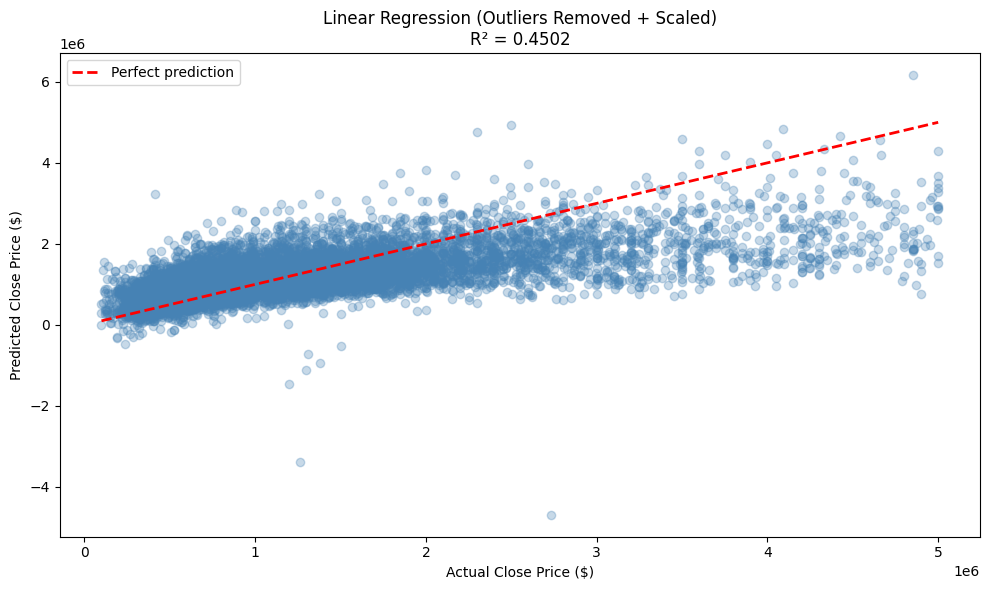

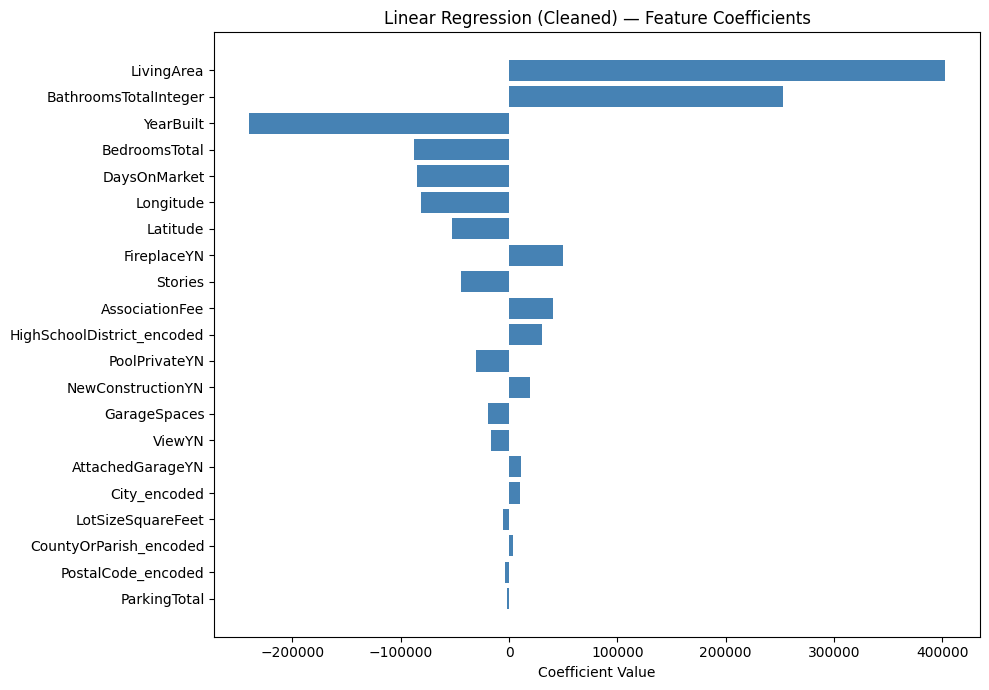

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_clean, y_pred_clean, alpha=0.3, color="steelblue")
plt.plot(
    [y_test_clean.min(), y_test_clean.max()],
    [y_test_clean.min(), y_test_clean.max()],
    "r--", linewidth=2, label="Perfect prediction"
)
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title(f"Linear Regression (Outliers Removed + Scaled)\nR² = {r2_clean:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

# Feature coefficients plot
importance_clean = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model_lr_clean.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(importance_clean["Feature"], importance_clean["Coefficient"], color="steelblue")
plt.xlabel("Coefficient Value")
plt.title("Linear Regression (Cleaned) — Feature Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
results = pd.DataFrame({
    "Model": ["Linear Regression (Baseline)"],
    "R2_Score": [round(r2_lr, 4)],
    "MAE": [round(mae_lr, 0)],
    "Test_Month": ["2026-05"]
})

print(results)

results.to_csv(
    r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\model_results.csv",
    index=False
)
print("\nResults saved!")

                          Model  R2_Score       MAE Test_Month
0  Linear Regression (Baseline)    0.2995  571147.0    2026-05

Results saved!


LINEAR REGRESSION + LOG TRANSFORM
R² Score:            0.2383
Mean Absolute Error: $416,379


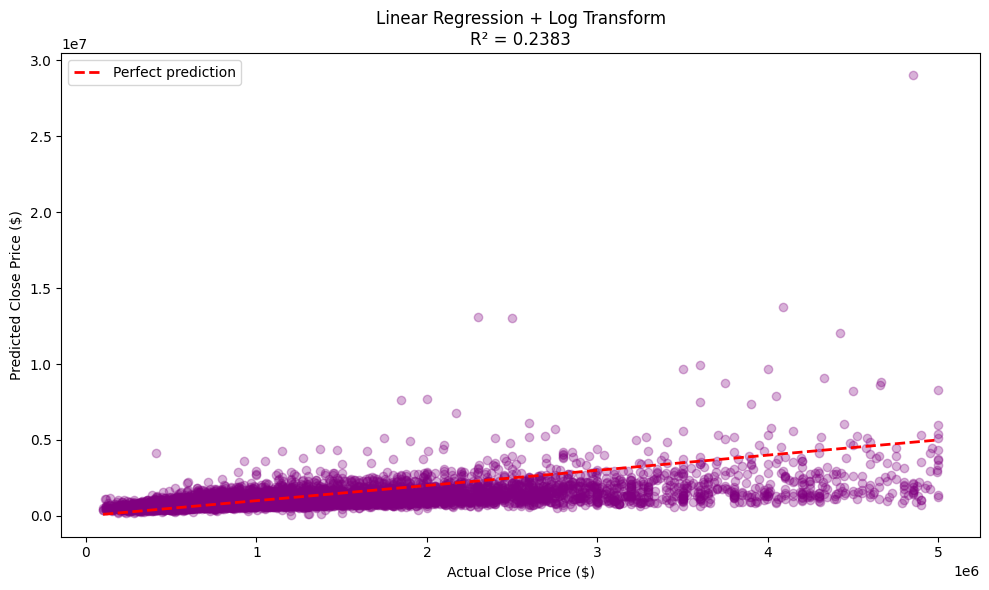


SUMMARY SO FAR:
  Original Linear Regression:          R² = 0.2995
  LR + Outliers Removed + Scaled:      R² = 0.4502
  LR + Outliers Removed + Log + Scaled: R² = 0.2383


In [18]:
# Log transform the target
y_train_log = np.log(y_train_clean)

# Scale features
scaler_log = StandardScaler()
X_train_log_scaled = scaler_log.fit_transform(X_train_clean)
X_test_log_scaled  = scaler_log.transform(X_test_clean)

# Train on log-transformed target + scaled features
model_lr_log = LinearRegression()
model_lr_log.fit(X_train_log_scaled, y_train_log)

# Predict and convert back to dollars
y_pred_log    = model_lr_log.predict(X_test_log_scaled)
y_pred_actual = np.exp(y_pred_log)

r2_log  = r2_score(y_test_clean, y_pred_actual)
mae_log = mean_absolute_error(y_test_clean, y_pred_actual)

print("=" * 40)
print("LINEAR REGRESSION + LOG TRANSFORM")
print("=" * 40)
print(f"R² Score:            {r2_log:.4f}")
print(f"Mean Absolute Error: ${mae_log:,.0f}")
print("=" * 40)

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_clean, y_pred_actual, alpha=0.3, color="purple")
plt.plot(
    [y_test_clean.min(), y_test_clean.max()],
    [y_test_clean.min(), y_test_clean.max()],
    "r--", linewidth=2, label="Perfect prediction"
)
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title(f"Linear Regression + Log Transform\nR² = {r2_log:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

print("\nSUMMARY SO FAR:")
print(f"  Original Linear Regression:          R² = 0.2995")
print(f"  LR + Outliers Removed + Scaled:      R² = {r2_clean:.4f}")
print(f"  LR + Outliers Removed + Log + Scaled: R² = {r2_log:.4f}")